<h1>Проект: Прогнозирование оттока клиентов фитнес-центра "Культурист-датасаентист" (основы машинного обучения).</h1>

<b> Описание: </b>  
Сеть фитнес-центров «Культурист-датасаентист» разрабатывает стратегию взаимодействия с клиентами на основе аналитических данных.  
Сеть столкнулась с распространенной проблемой - отток клиентов.  
Их отдел по работе с клиентами «Культуриста-датасаентиста» перевёл в электронный вид множество клиентских анкет.  


<b> Задача: </b>  
Провести анализ предоставленных данных и подготовить план действий по удержанию клиентов, а именно:  
+ научиться прогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;  
+ сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;  
+ проанализировать основные признаки, наиболее сильно влияющие на отток;  
+ сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:  
1) выделить целевые группы клиентов;  
2) предложить меры по снижению оттока;  
3) определить другие особенности взаимодействия с клиентами.

<b> Данные предоставлены в файле: /datasets/gym_churn.csv </b>   

<i>Данные клиента за предыдущий до проверки факта оттока месяц:</i>  
+ 'gender' — пол;  
+ 'Near_Location' — проживание или работа в районе, где находится фитнес-центр;  
+ 'Partner' — сотрудник компании-партнёра клуба (сотрудничество с компаниями, чьи сотрудники могут получать скидки на абонемент — в таком случае фитнес-центр хранит информацию о работодателе клиента);  
+ Promo_friends — факт первоначальной записи в рамках акции «приведи друга» (использовал промо-код от знакомого при оплате первого абонемента);  
+ 'Phone' — наличие контактного телефона;  
+ 'Age' — возраст;  
+ 'Lifetime' — время с момента первого обращения в фитнес-центр (в месяцах).  

<i>Информация на основе журнала посещений, покупок и информация о текущем статусе абонемента клиента:</i>  
+ 'Contract_period' — длительность текущего действующего абонемента (месяц, 6 месяцев, год);  
+ 'Month_to_end_contract' — срок до окончания текущего действующего абонемента (в месяцах);  
+ 'Group_visits' — факт посещения групповых занятий;  
+ 'Avg_class_frequency_total' — средняя частота посещений в неделю за все время с начала действия абонемента;  
+ 'Avg_class_frequency_current_month' — средняя частота посещений в неделю за предыдущий месяц;  
+ 'Avg_additional_charges_total' — суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон.  
+ 'Churn' — факт оттока в текущем месяце.

[1. Загрузка, обзор и анализ предоставленных данных.](#1)  
[2. Подготовка данных для дальнейшего анализа.](#2)  
    [2.1. Изменение стиля заголовков.](#2.1)   
    [2.2. Проверка данных на пропуски.](#2.2)  
    [2.3. Проверка данных на дубликаты.](#2.3)  
[3. Исследовательский анализ данных (EDA).](#3)  
    [3.1. Средние значения и стандартные отклонения признаков.](#3.1)  
    [3.2. Распределение средних значений признаков в 2-х группах: тех кто ушел и кто остался.](#3.2)  
    [3.3. Построение стобчатых гистограмм и распределений признаков для оставшихся и ушедших клиентов.](#3.3)
    [3.4. Матрица корреляции признаков.](#3.4)  
[4. Построение модели прогнозирования оттока клиентов.](#4)  
    [4.1. Разбивка данных на обучающую и валидационную выборку.](#4.1)  
    [4.2. Обучение моделей:](#4.2)  
        [4.2.1. Способ логистической регрессии.](#4.2.1)  
        [4.2.2. Способ случайного леса.](#4.2.2)  
    [4.3. Оценка качества моделей.](#4.3)  
[5. Кластеризация клиентов.](#5)  
    [5.1. Стандартизация данных.](#5.1)  
    [5.2. Построение матрицы расстояний. Нарисовка дендрограммы.](#5.2)  
    [5.3. Обучение модели кластеризации. Прогноз кластеров клиентов.](#5.3)  
    [5.4. Распределение средних значений признаков по кластерам.](#5.4)  
    [5.5. Визуализация распределения признаков для кластеров.](#5.5)  
    [5.6. Подсчет доли оттока для каждого полученного кластера.](#5.6)  
[6. Выводы и рекомендации.](#6)

<h1>1. Загрузка, обзор и анализ предоставленных данных.</h1>
<a id='1'></a>

In [1]:
# импорт библиотек: 
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# загрузим файл 
gym = pd.read_csv('/datasets/gym_churn.csv')

In [3]:
# настроим полный вывод данных для удобства
pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.options.display.max_colwidth = 210
pd.options.display.float_format = '{:.2f}'.format

In [4]:
# добавим функцию для оптимизации
def check_df (df):
    display(df.info()) # общая информация 
    display(df.head()) # первые 5 строк

In [5]:
check_df(gym)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

None

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.23,5.00,3,0.02,0.00,0
1,0,1,0,0,1,12,1,31,113.20,12.00,7,1.92,1.91,0
2,0,1,1,0,1,1,0,28,129.45,1.00,2,1.86,1.74,0
3,0,1,1,1,1,12,1,33,62.67,12.00,2,3.21,3.36,0
4,1,1,1,1,1,1,0,26,198.36,1.00,3,1.11,1.12,0


<u>Подвывод:</u>   
    
    1. Данные содержатся в одном датасете 'gym'. Таблица состоит из 4.000 строк и 14 столбцов:  
    1) пол клиента;   
    2) проживание или работа в районе, где находится фитнес-центр;  
    3) сотрудник компании-партнёра клуба;  
    4) факт первоначальной записи в рамках акции «приведи друга»;  
    5) наличие контактного телефона;  
    6) возраст клиента;  
    7) время с момента первого обращения в фитнес-центр;  
    8) длительность текущего действующего абонемента;  
    9) срок до окончания текущего действующего абонемента;  
    10) факт посещения групповых занятий;  
    11) средняя частота посещений в неделю за все время с начала действия абонемента;  
    12) средняя частота посещений в неделю за предыдущий месяц;  
    13) суммарная выручка от других услуг фитнес-центра;  
    14) факт оттока в текущем месяце.  
    
    2. Можем наблюдать проблемы со стилизацией столбцов.
    
    3. Большая часть значений представленны в бинарном виде. В целом все понятно: 1 - это характерно для клиента; 0 - не характерно для клиента. Исключение столбец с полом клиента, будем условно считать, что 1 - мужской, 0 - женский, для дальнейшего удобства.

<h1>2. Подготовка данных для дальнейшего анализа.</h1>
<a id='2'></a>

<b>2.1. Изменение стиля заголовков.</b>
<a id='2.1'></a>

In [6]:
# приведем названия столбцов в нижнему регистру
gym.columns = gym.columns.str.lower()
gym.columns

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='object')

успех! идем дальше.

<b>2.2. Проверка данных на пропуски.</b>
<a id='2.2'></a>

In [7]:
# посмотрим на пропуски
gym.isna().sum()

gender                               0
near_location                        0
partner                              0
promo_friends                        0
phone                                0
contract_period                      0
group_visits                         0
age                                  0
avg_additional_charges_total         0
month_to_end_contract                0
lifetime                             0
avg_class_frequency_total            0
avg_class_frequency_current_month    0
churn                                0
dtype: int64

отсутствуют

<b>2.3. Проверка данных на дубликаты.</b>
<a id='2.3'></a>

In [8]:
# посмотрим на дубликаты
gym.duplicated().sum()

0

отсутствуют

<h1>3. Исследовательский анализ данных (EDA).</h1>
<a id='3'></a>

<b>3.1. Средние значения и стандартные отклонения признаков.</b>
<a id='3.1'></a>

In [9]:
gym.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,0.51,0.85,0.49,0.31,0.90,4.68,0.41,29.18,146.94,4.32,3.72,1.88,1.77,0.27
std,0.50,0.36,0.50,0.46,0.30,4.55,0.49,3.26,96.36,4.19,3.75,0.97,1.05,0.44
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,18.00,0.15,1.00,0.00,0.00,0.00,0.00
25%,0.00,1.00,0.00,0.00,1.00,1.00,0.00,27.00,68.87,1.00,1.00,1.18,0.96,0.00
50%,1.00,1.00,0.00,0.00,1.00,1.00,0.00,29.00,136.22,1.00,3.00,1.83,1.72,0.00
75%,1.00,1.00,1.00,1.00,1.00,6.00,1.00,31.00,210.95,6.00,5.00,2.54,2.51,1.00
max,1.00,1.00,1.00,1.00,1.00,12.00,1.00,41.00,552.59,12.00,31.00,6.02,6.15,1.00


<u> Сформируем представление о среднестатическом клиенте нашего фитнес центра на основе данных:</u>  
+ не важно какого пола клиент (в фитнес-центр ходят в равной степени как женщины, так и мужчины);  
+ клиент живет или работает недалеко от фитнес-центра;  
+ не важно клиент от компании-партнера или нет (в фитнес-центр ходят в равной степени как просто клиенты, так и от компании-партнера);  
+ скорее всего клиент пришел не по акции "приведи друга";  
+ клиент оставил свой номер телефона;  
+ у клиента действует абонемент на 5 месяцев (по полученной таблице, т.е. будем придерживаться, что среднестатистический клиент приобретает абонемент на 6 месяцев, т.к. у нас всего 3 вида абонементы: на 1 месяц, на 6 месяцев и на 12 месяцев);  
+ чуть больше вероятность, что клиент не посещает групповые занятия;  
+ возраст клиента 29 лет;  
+ клиент тратит на дополнительные услуги фитнес-центра примерно 147 у.е.;  
+ абонемент у клиента заканчивается через 4 месяца;
+ в среднем клиент в фитнес-центр уже 4 месяца; 
+ посещает фитнес-центр 2 раза в неделю за все время дейтсвования абонемента.  

<b>3.2. Распределение средних значений признаков в 2-х группах: тех кто ушел и кто остался.</b>
<a id='3.2'></a>

In [10]:
# посмотрим сколько клиентов осталось, а сколько ушло
gym['churn'].value_counts()

0    2939
1    1061
Name: churn, dtype: int64

In [11]:
# в процентах
gym['churn'].value_counts(normalize=True) * 100

0   73.47
1   26.52
Name: churn, dtype: float64

отток составляет почти четверть клиентов от общего числа (27%), достаточно большой показатель.

In [12]:
# сгруппируем по оттоку и посчитаем средние по всем признакам
gym.groupby('churn').agg('mean').reset_index()

,churn,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
0,0,0.51,0.87,0.53,0.35,0.90,5.75,0.46,29.98,158.45,5.28,4.71,2.02,2.03
1,1,0.51,0.77,0.36,0.18,0.90,1.73,0.27,26.99,115.08,1.66,0.99,1.47,1.04


<u>Подвывод:</u>  
+ отток клиентов по половому признаку в равной степени, уходят как мужчины так и женщины;  
+ 87% оставшихся клиентов живут или работают недалеко от фитнес-центра, ушедших клиентов - 77%;  
+ 53% оставшихся клиентов от компании-партнеров, ушли - 36%;  
+ 35% оставшихся клиентов воспользовались акцией "приведи друга", ушедшие - 18%;  
+ в равной степени (90%) клиентов как оставшихся, так и ушедших оставили свой номер телефона;
+ у оставшихся клиентов средняя продолжительность абонементов 5,8 месяцев, среди ушедших 1,7 месяцев;  
+ 46% оставшихся клиентов посещают групплвые занятия, среди ушедших таких было 27%;  
+ средней возраст оставшихся клиентов 30 лет, ушедших - 27 лет;  
+ оставшиеся клиенты тратят на дополнительные услуги фитнес центра в среднем 158 у.е., из ушедших тратили 115 у.е.;  
+ средний срок абонемента у оставшихся клиентов составляет 5,3 месяца, у ушедших - 1,7 месяца;  
+ среднее время посещения фитнес-центра у олставшихся клиентов 4,7 месяцев, у ушедших - 1 месяц;  
+ средняя частота посещений в неделю за все время у оставшихся клиентов составляет 2 дня, у ушедших 1,5; 
+ средняя частота посещений в неделю за предыдущий месяц у оставшихся клиентов составляет также 2 дня, у ушедших - 1 день. 

<b>3.3. Построение стобчатых гистограмм и распределений признаков для оставшихся и ушедших клиентов.</b>
<a id='3.3'></a>

In [13]:
# сразу зададим функции для анализа и построения графика для удобства дальнейшего исследования
# начнем с бинарных значений признаков

def analyse_and_plot(gym, feature):
    data = gym.groupby(feature).agg({'churn': ['count', 'sum']}).reset_index()
    data.columns = [feature, 'total_clients', 'churn_clients']
    data['difference'] = round(data['churn_clients'] / data['total_clients'], 2)
    print(data)

    title_clients = f"Сравнение общего числа клиентов и числа ушедших клиентов по признаку: '{feature}'"
    xlabel = 'Значение признака'
    ylabel_clients = 'Количество клиентов'
    
    data.plot(x=feature, y=['total_clients', 'churn_clients'], kind='bar', figsize=(8, 4), legend=True, 
              color=['green', 'red'], 
              label=['Общее число клиентов', 'Число ушедших клиентов'])
    plt.title(title_clients)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel_clients)
    plt.grid(True)
    plt.show()

    title_difference = f"Доля ушедших клиентов в зависимости от признака: '{feature}'"
    ylabel_difference = 'Доля ушедших клиентов'
    
    data.plot(x=feature, y='difference', kind='bar', figsize=(8, 4), legend=True, color='blue')
    plt.title(title_difference)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel_difference)
    plt.grid(True)
    plt.show()

In [14]:
# и для количетсвенных значений признаков
def histplot(feature, title, xlabel, ylabel, bins):
    plt.figure(figsize=(8, 4))
    plt.hist(gym[feature], bins, color='green', label='Общее число клиентов')
    plt.hist(gym.query('churn == 1')[feature], bins, color='red', label='Число ушедших клиентов')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel) 
    plt.legend()
    plt.grid(True)
    plt.show()

def analyse_numerical(feature, bins):
    title = f"Сравнение общего числа клиентов и числа ушедших клиентов по признаку: '{feature}'"
    xlabel = 'Значение признака'
    ylabel = 'Количество клиентов'
    histplot(feature=feature, title=title, xlabel=xlabel, ylabel=ylabel, bins=bins)
    
    print(f'Среднее и медиана признака для всех клиентов: {int(gym[feature].mean())}, {int(gym[feature].median())}')
    print(f'Среднее и медиана признака для ушедших клиентов: {int(gym.query("churn == 1")[feature].mean())}, {int(gym.query("churn == 1")[feature].median())}')

   пол  total_clients  churn_clients  difference
0    0           1959            519        0.26
1    1           2041            542        0.27


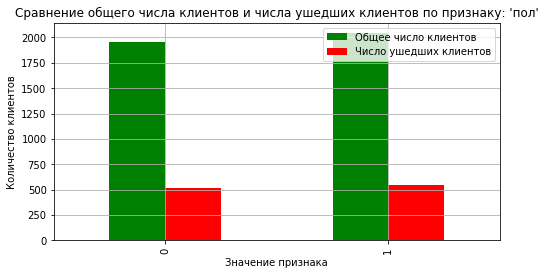

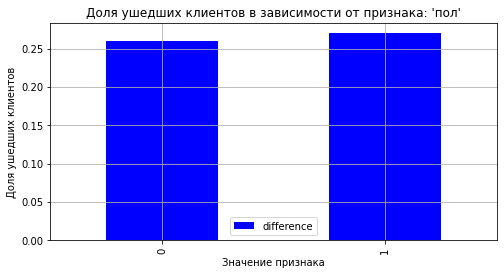

In [15]:
# теперь поочередно посмотрим оставшихся и ушедших клиентов по признакам
# начнем с полового признака
gym['пол'] = gym['gender']
analyse_and_plot(gym, 'пол')

Ещё раз убеждаемся, что факт оттока клиентов не связан с половым признаком. Различия незначительны.

   проживание или работа в районе, где находится фитнес-центр  total_clients  \
0                                                           0            619   
1                                                           1           3381   

   churn_clients  difference  
0            246        0.40  
1            815        0.24  


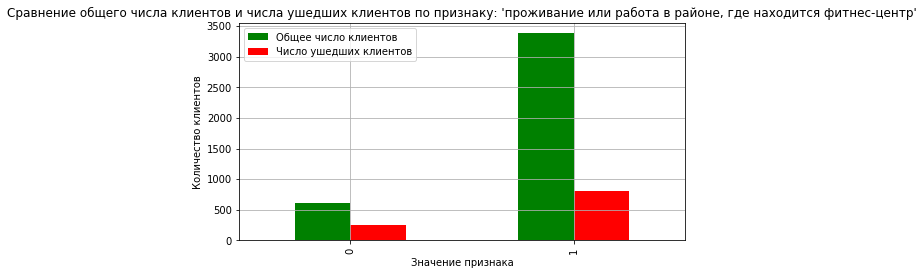

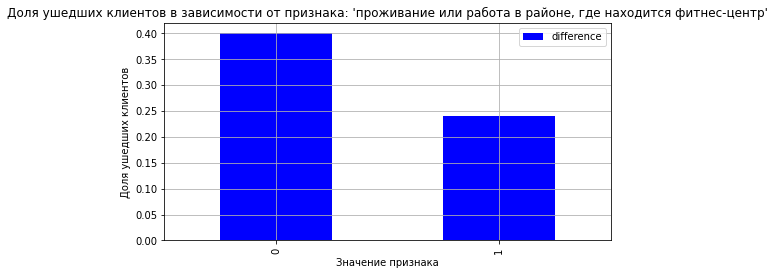

In [16]:
# теперь посмотрим признак проживания или работы рядом с фитнес-центром
gym['проживание или работа в районе, где находится фитнес-центр'] = gym['near_location']
analyse_and_plot(gym, 'проживание или работа в районе, где находится фитнес-центр')

Клиентов, проживающих или работающих вблизи фитнес-центра во много раз больше, чем клиентов с других районов, пользующихся услугами фитнес центра. Доля ушедших клиентов почти в 2 раза меньше, чем оставшихся. Можем сделать вывод, что клиенты, проживающие или работающие поблизости - это важный и положительный факт для нас.

   сотрудник компании-партнёра клуба  total_clients  churn_clients  difference
0                                  0           2053            684        0.33
1                                  1           1947            377        0.19


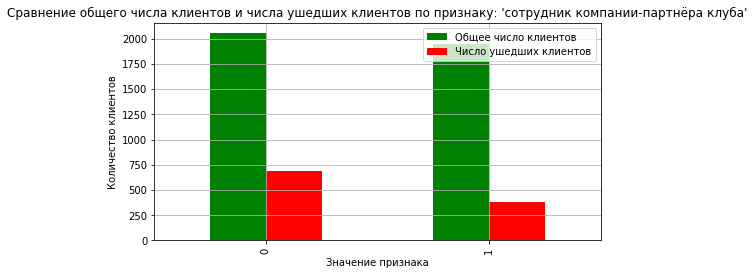

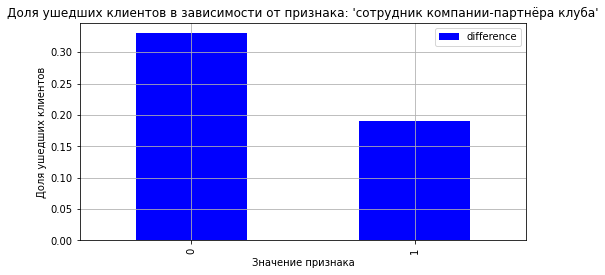

In [17]:
# теперь посмотрим на сотрудников компании-партнера
gym['сотрудник компании-партнёра клуба'] = gym['partner']
analyse_and_plot(gym, 'сотрудник компании-партнёра клуба')

Количество клиентов, пришедших как сотрудники компании-партнера, и других клиентов практически поровну. Однако отток клиентов от компании партнеры значительно ниже, чем у других клиентов. Пометим что это немаловажный признак.

   использовал промо-код «приведи друга»  total_clients  churn_clients  \
0                                      0           2766            866   
1                                      1           1234            195   

   difference  
0        0.31  
1        0.16  


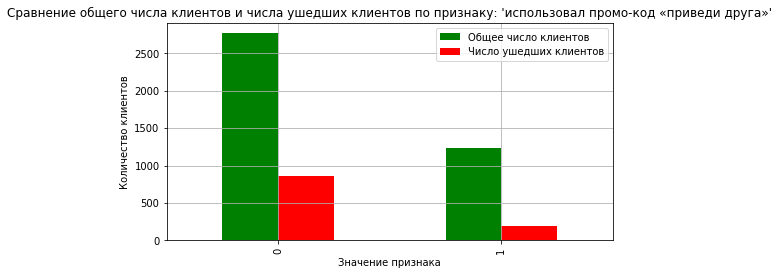

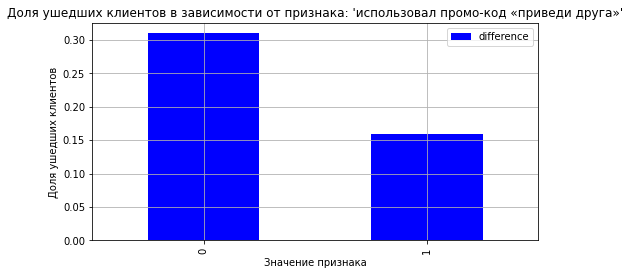

In [18]:
# теперь клиенты, воспользовавшиеся акцией
gym['использовал промо-код «приведи друга»'] = gym['promo_friends']
analyse_and_plot(gym, 'использовал промо-код «приведи друга»')

Клиентов, пришедших по промокоду, не так много, по сравнению с другими клиентами. Однако отток таких  клиентов значительно ниже. Отметим, что акция работает.

   наличие контактного телефона  total_clients  churn_clients  difference
0                             0            386            103        0.27
1                             1           3614            958        0.27


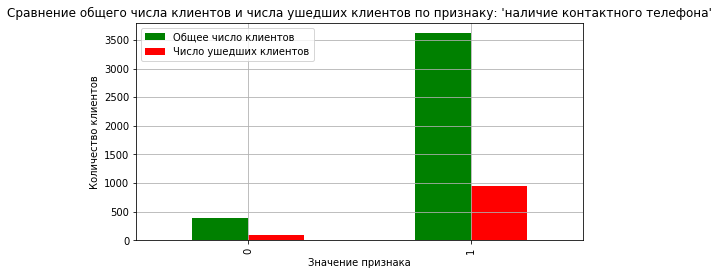

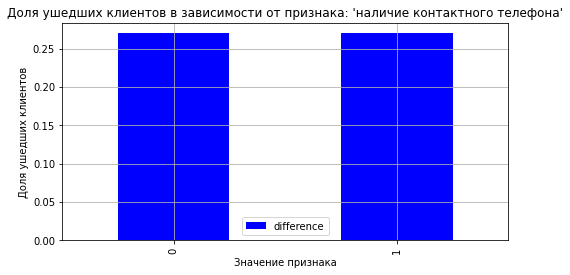

In [19]:
# теперь клиентов, оставивших свой мобильный номер телефона
gym['наличие контактного телефона'] = gym['phone']
analyse_and_plot(gym, 'наличие контактного телефона')

Клиентов, которые оставляют свой контактный номер телефон во много раз больше, чем тех, кто воздержался от этого. Однако отток клиентов, что таких, что других одинаков. То есть факт оставления контактного телефона для нас не так уж и важен.

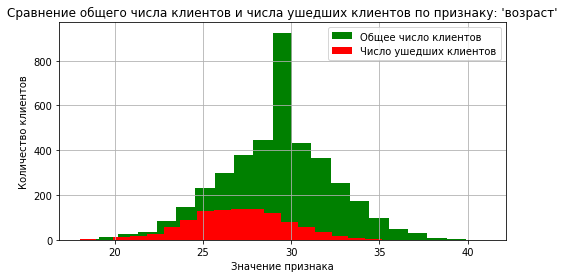

Среднее и медиана признака для всех клиентов: 29, 29
Среднее и медиана признака для ушедших клиентов: 26, 27


In [20]:
# возраст клиентов
gym['возраст'] = gym['age']
analyse_numerical('возраст', 21)

Отметим, что у нас больше клиентов в возрасте от 25 до 33 лет. Больше отток клиентов идет по возрасту до 35 лет. Среди клиентов от 35 лет оттока практически нет.

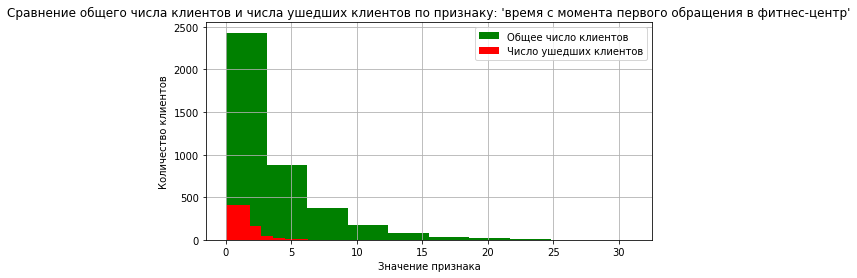

Среднее и медиана признака для всех клиентов: 3, 3
Среднее и медиана признака для ушедших клиентов: 0, 1


In [21]:
# время с момента первого обращения в фитнес-центр
gym['время с момента первого обращения в фитнес-центр'] = gym['lifetime']
analyse_numerical('время с момента первого обращения в фитнес-центр', 10)

Отметим, что клиенты пришедшие в фитнес-центр 6-7 месяцев назад не покидают его. То есть, так называеме "старички" надежнее, чем " новички". 

   длительность текущего действующего абонемента  total_clients  \
0                                              1           2207   
1                                              6            833   
2                                             12            960   

   churn_clients  difference  
0            934        0.42  
1            104        0.12  
2             23        0.02  


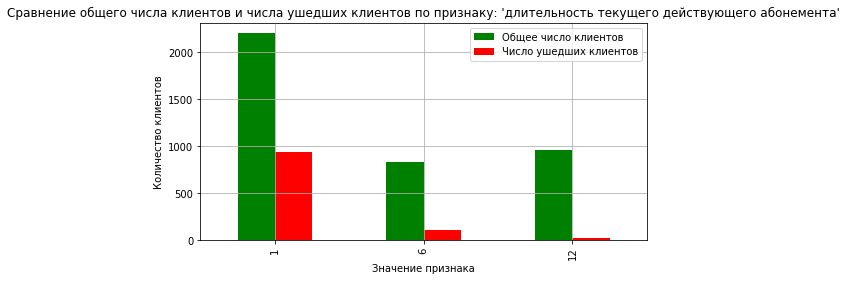

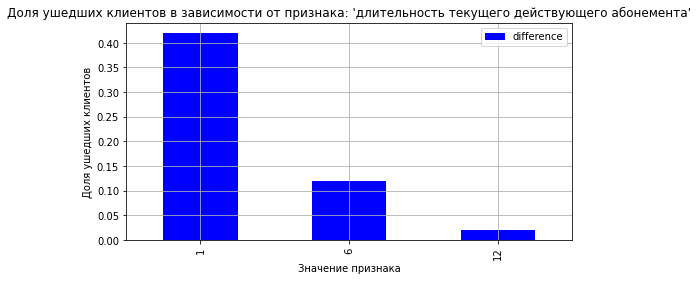

In [22]:
# длительность текущего действующего абонемента
gym['длительность текущего действующего абонемента'] = gym['contract_period']
analyse_and_plot(gym, 'длительность текущего действующего абонемента')

Отметим, что клиенты в основном приобретают кроткосрочный абонемент на 1 месяц, но у таких клиентов и достаточно большой отток. Хоть клиентов приобретающих более долгосрочные абонементы (на 6 и 12 месяцев) в разы меньше, но и отток среди таких клиентов меньше. Отметим, что признак достаточно важный для нас.

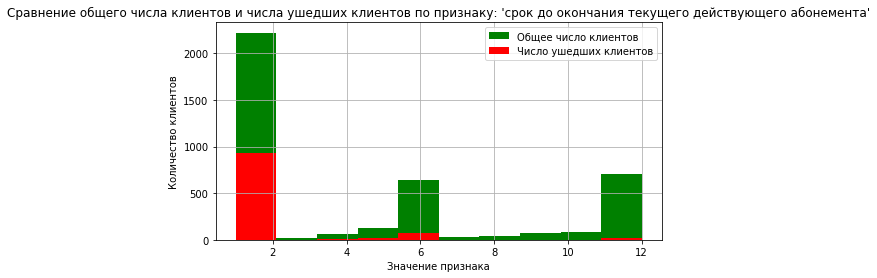

Среднее и медиана признака для всех клиентов: 4, 1
Среднее и медиана признака для ушедших клиентов: 1, 1


In [23]:
# срок до окончания текущего действующего абонемента
gym['срок до окончания текущего действующего абонемента'] = gym['month_to_end_contract']
analyse_numerical('срок до окончания текущего действующего абонемента', 10)

У многих клиентов абонемент закончится через месяц. 

   факт посещения групповых занятий  total_clients  churn_clients  difference
0                                 0           2351            776        0.33
1                                 1           1649            285        0.17


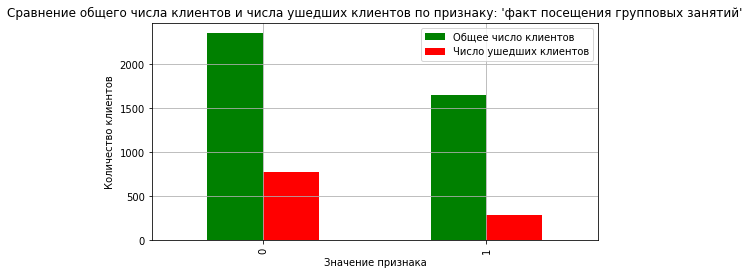

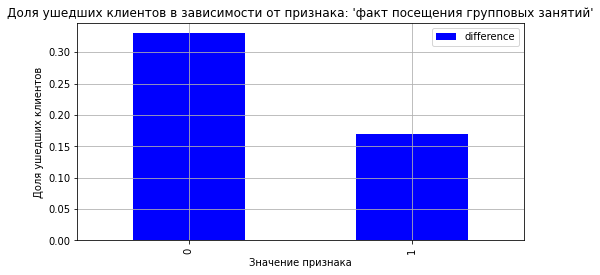

In [24]:
# факт посещения групповых занятий
gym['факт посещения групповых занятий'] = gym['group_visits']
analyse_and_plot(gym, 'факт посещения групповых занятий')

Клиентов, посещающих групповые занятия меньше, чем остальных клиентов. Но доля оттока среди клиентов, посещающих групповые занятия ниже. Отметим, что это немаловажный факт.

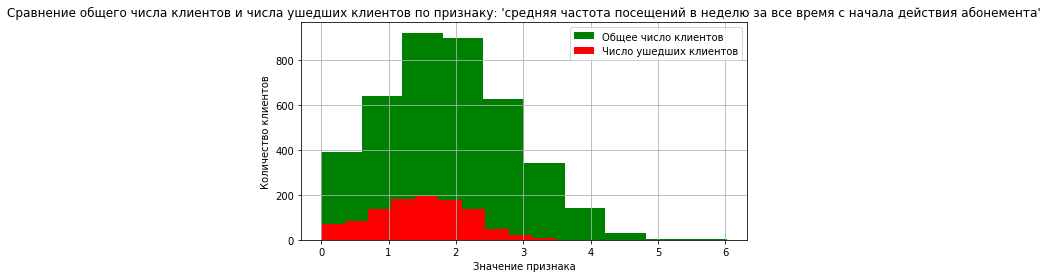

Среднее и медиана признака для всех клиентов: 1, 1
Среднее и медиана признака для ушедших клиентов: 1, 1


In [25]:
# средняя частота посещений в неделю за все время с начала действия абонемента
gym['средняя частота посещений в неделю за все время с начала действия абонемента'] = gym['avg_class_frequency_total']
analyse_numerical('средняя частота посещений в неделю за все время с начала действия абонемента', 10)

Ушедшие клиенты посещали фитнес центр в среднем 1-2 раза в неделю. Оставшиеся могут и чаще.

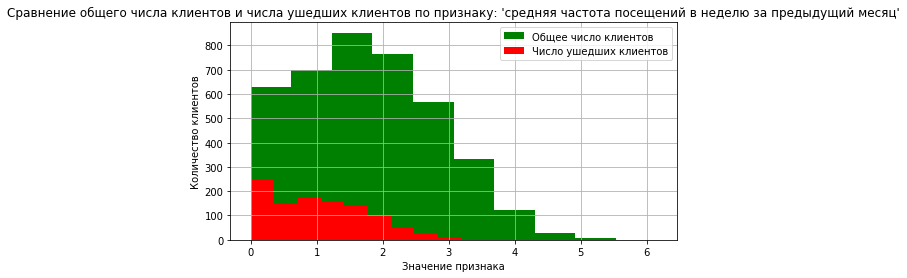

Среднее и медиана признака для всех клиентов: 1, 1
Среднее и медиана признака для ушедших клиентов: 1, 0


In [26]:
# средняя частота посещений в неделю за предыдущий месяц
gym['средняя частота посещений в неделю за предыдущий месяц'] = gym['avg_class_frequency_current_month']
analyse_numerical('средняя частота посещений в неделю за предыдущий месяц', 10)

За предыдущий месяц ушедшие клиенты посещали фитнес-центр в основном 1 раз в неделю. В то время как другие 2-3 раза.

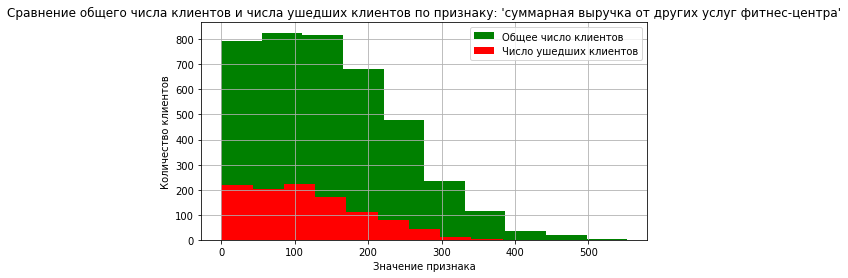

Среднее и медиана признака для всех клиентов: 146, 136
Среднее и медиана признака для ушедших клиентов: 115, 103


In [27]:
# суммарная выручка от других услуг фитнес-центра
gym['суммарная выручка от других услуг фитнес-центра'] = gym['avg_additional_charges_total']
analyse_numerical('суммарная выручка от других услуг фитнес-центра', 10)

Видим, что ушедшие клиенты меньше тратили на дополнительные услуги фитнес-центра, нежели другие клиенты.

<b>3.4. Матрица корреляции признаков.</b>
<a id='3.4'></a>

In [28]:
gym.rename(columns={
    'gender': 'пол', 
    'near_location': 'проживание или работа в районе, где находится фитнес-центр', 
    'partner': 'сотрудник компании-партнёра клуба', 
    'promo_friends': 'использовал промо-код «приведи друга»',
    'phone': 'наличие контактного телефона',
    'age': 'возраст',
    'lifetime': 'время с момента первого обращения в фитнес-центр',
    'contract_period': 'длительность текущего действующего абонемента',
    'month_to_end_contract': 'срок до окончания текущего действующего абонемента',
    'group_visits': 'факт посещения групповых занятий',
    'avg_class_frequency_total': 'средняя частота посещений в неделю за все время с начала действия абонемента',
    'avg_class_frequency_current_month': 'средняя частота посещений в неделю за предыдущий месяц',
    'avg_additional_charges_total': 'суммарная выручка от других услуг фитнес-центра',
    'churn': 'факт оттока в текущем месяце'
}, inplace=True)
gym = gym.loc[:, ~gym.columns.duplicated()]

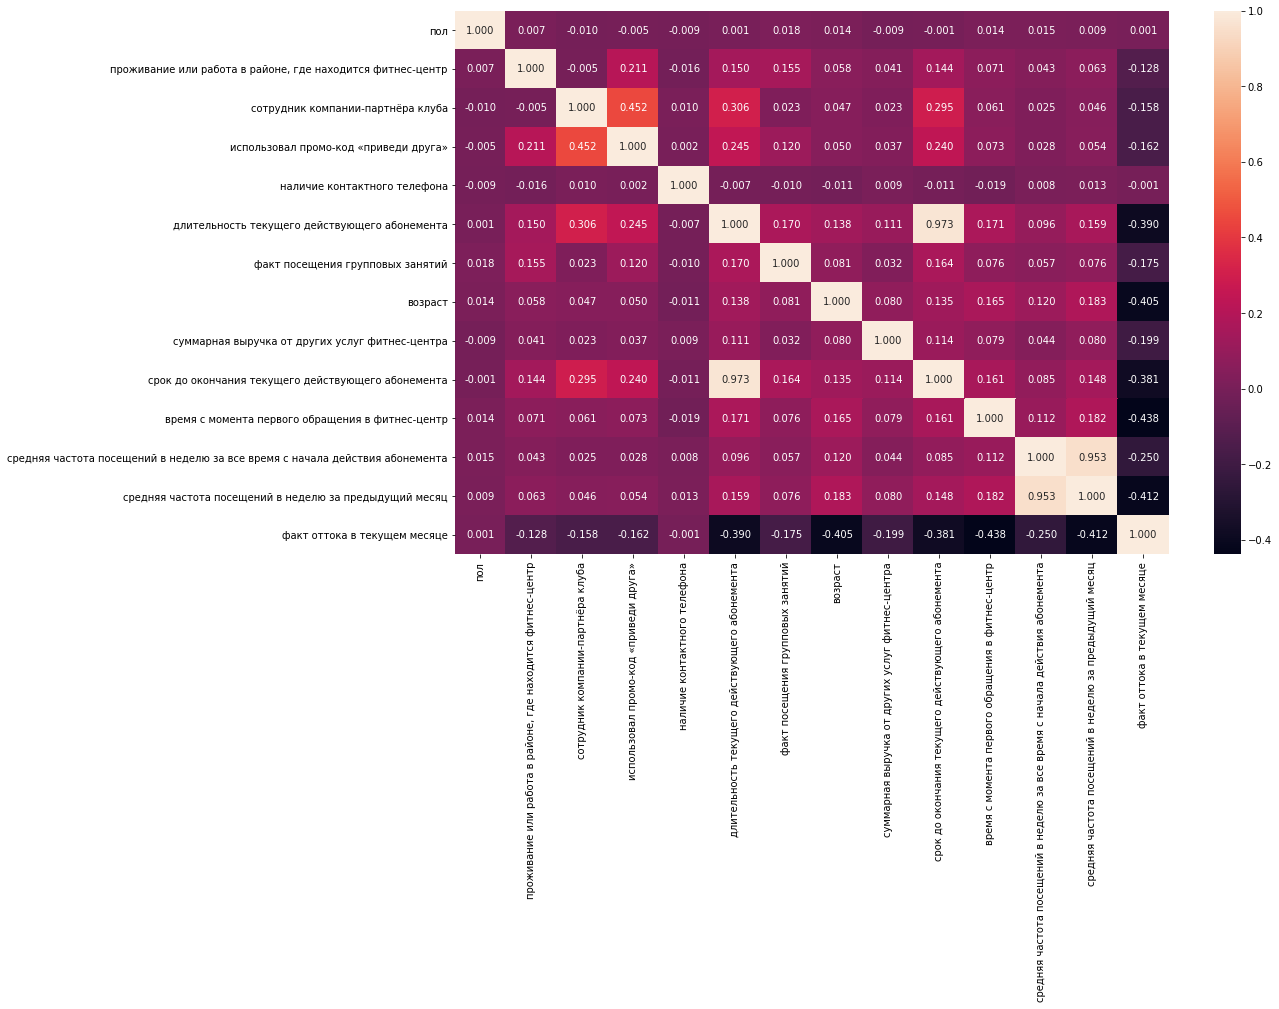

In [29]:
# построим корреляционную матрицу признаков и целевой переменной клиентов фитнес-центра
plt.figure(figsize=(16, 10))
sns.heatmap(gym.corr(), annot = True, fmt='.3f')
plt.show()

Отметим:

+ у признаков 'пол' и 'наличие контактного телефона' нет не только взаимосвязи с целевой переменной, но и с другими признаками;  
+ высокую линейную корреляцию имеют признаки 'срок до окнчания текущего действующего абонемента' и 'длительность текущего действующего абонемента' (0.973);  
+ высокую линейную корреляцию имеют признаки 'средняя частота посещений в неделю за предыдущий месяц' и 'средняя частота посещений в неделю за все время с начала действия абонемента' (0.953);  
+ остальные признаки практически не влияют на целевую переменную.

<h1>4. Построение модели прогнозирования оттока клиентов.</h1>
<a id='4'></a>

<b>4.1. Разбивка данных на обучающую и валидационную выборку.</b>
<a id='4.1'></a>

In [30]:
gym.rename(columns={
    'пол': 'gender', 
    'проживание или работа в районе, где находится фитнес-центр': 'near_location', 
    'сотрудник компании-партнёра клуба': 'partner', 
    'использовал промо-код «приведи друга»': 'promo_friends',
    'наличие контактного телефона': 'phone',
    'возраст': 'age',
    'время с момента первого обращения в фитнес-центр': 'lifetime',
    'длительность текущего действующего абонемента': 'contract_period',
    'срок до окончания текущего действующего абонемента': 'month_to_end_contract',
    'факт посещения групповых занятий': 'group_visits',
    'средняя частота посещений в неделю за все время с начала действия абонемента': 'avg_class_frequency_total',
    'средняя частота посещений в неделю за предыдущий месяц': 'avg_class_frequency_current_month',
    'суммарная выручка от других услуг фитнес-центра': 'avg_additional_charges_total',
    'факт оттока в текущем месяце': 'churn'
}, inplace=True)

In [31]:
# признаки "пол" и "наличие контактного номера" не несут для нас никакого смысла, избавимся от них
gym_filtered = gym.drop(['gender', 'phone'], axis=1)

In [32]:
# разделим данные на признаки и целевую переменную
X = gym.drop('churn', axis = 1)
y = gym['churn']

# разделим выборку на обучающую и валидационную в соотношении 80/20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# стандартизируем данные
scaler = StandardScaler()
scaler.fit(X_train)
X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

In [33]:
# напишем функцию для оптимизации вывода значений 
def all_metrics(y_true, y_pred, y_proba, title = 'Метрики классификации'):
    print(title)
    print('\tAccuracy: {:.2f}'.format(accuracy_score(y_true, y_pred)))
    print('\tPrecision: {:.2f}'.format(precision_score(y_true, y_pred)))
    print('\tRecall: {:.2f}'.format(recall_score(y_true, y_pred)))
    print('\tF1: {:.2f}'.format(f1_score(y_true, y_pred)))
    print('\tROC_AUC: {:.2f}'.format(roc_auc_score(y_true, y_proba)))

<b>4.2. Обучение моделей:</b>
<a id='4.2'></a>

<b>4.2.1. Способ логистической регрессии.</b>
<a id='4.2.1'></a>

In [34]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_probabilities = lr_model.predict_proba(X_test)[:,1]

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<b>4.2.2. Способ случайного леса.</b>
<a id='4.2.2'></a>

In [35]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:,1]

<b>4.3. Оценка качества моделей.</b>
<a id='4.3'></a>

In [36]:
# посмотрим модель логистической регрессии
all_metrics(y_test, lr_predictions, lr_probabilities , title='Метрики для модели логистической регрессии:')

Метрики для модели логистической регрессии:
	Accuracy: 0.93
	Precision: 0.88
	Recall: 0.84
	F1: 0.86
	ROC_AUC: 0.97


In [37]:
# и случайного леса 
all_metrics(y_test, rf_predictions, rf_probabilities , title='Метрики для модели случайного леса:')

Метрики для модели случайного леса:
	Accuracy: 0.93
	Precision: 0.88
	Recall: 0.82
	F1: 0.85
	ROC_AUC: 0.97


In [38]:
# оценим важность признаков в модели логистической регрессии
coefficients = lr_model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients,
    'Importance': np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Coefficient,Importance
12,avg_class_frequency_current_month,-4.76,4.76
11,avg_class_frequency_total,4.23,4.23
4,phone,1.16,1.16
10,lifetime,-0.96,0.96
3,promo_friends,-0.66,0.66
6,group_visits,-0.48,0.48
2,partner,-0.28,0.28
0,gender,0.27,0.27
1,near_location,-0.18,0.18
9,month_to_end_contract,-0.14,0.14


In [39]:
# и теперь случайный лес
importances = rf_model.feature_importances_

feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

feature_importance_rf

,Feature,Importance
10,lifetime,0.28
12,avg_class_frequency_current_month,0.18
11,avg_class_frequency_total,0.13
7,age,0.12
9,month_to_end_contract,0.09
8,avg_additional_charges_total,0.09
5,contract_period,0.06
6,group_visits,0.02
3,promo_friends,0.01
0,gender,0.01


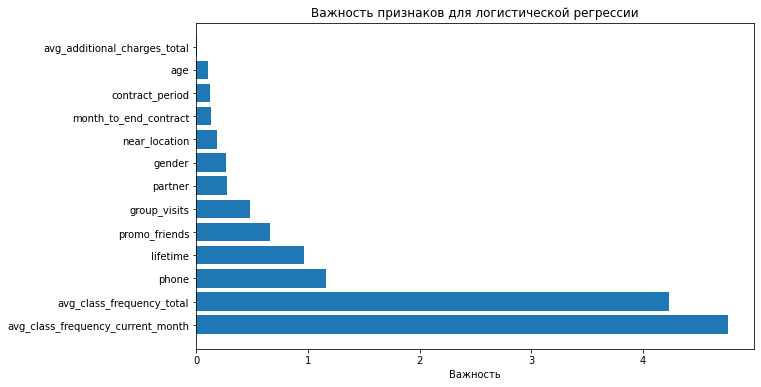

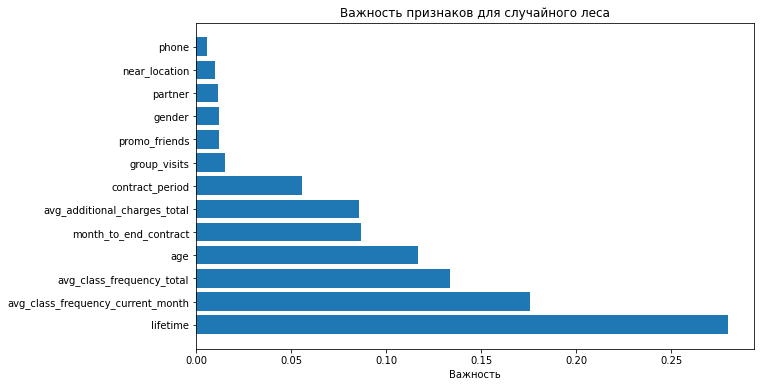

In [40]:
# провизуализируем
# для логистической регрессии
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Важность')
plt.title('Важность признаков для логистической регрессии')
plt.show()

# для случайного леса
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'])
plt.xlabel('Важность')
plt.title('Важность признаков для случайного леса')
plt.show()

Лучшие результаты показала модель логистической регрессии по всем метрикам.   
Сильно они не отличаются, и качество обеих моделей высокое.  
Остановимся на модели логистической регрессии.

<h1>5. Кластеризация клиентов.</h1>
<a id='5'></a>

<b>5.1. Стандартизация данных.</b>
<a id='5.1'></a>

In [41]:
# зададим модель стандартизатора и стандартизируем данные
scaler = StandardScaler()
X_st = scaler.fit_transform(X)

<b>5.2. Построение матрицы расстояний. Нарисовка дендрограммы.</b>
<a id='5.2'></a>

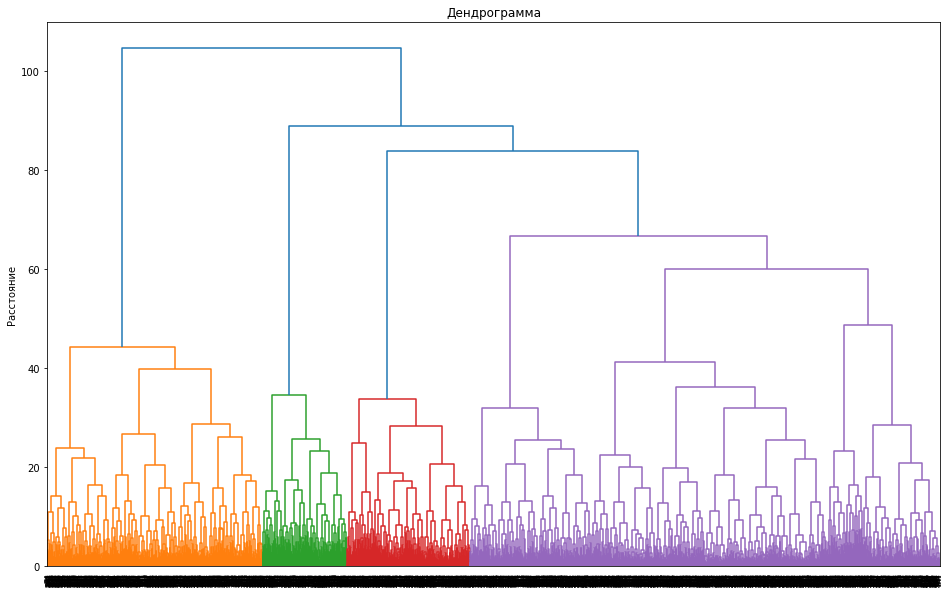

In [42]:
# построение матрицы расстояний с использованием метода 'ward'
Z = linkage(X_st, method='ward')

# построим дендограмму
plt.figure(figsize=(16, 10))
dendrogram(Z)
plt.title('Дендрограмма')
plt.ylabel('Расстояние')
plt.show()

По получившейся дендрограмме можно визуально оценить, сколько кластеров должно быть. Модель предложила 4 кластера (5 разных цветов на графике), но также можно разбить клиентов и на 5 кластеров.

<b>5.3. Обучение модели кластеризации. Прогноз кластеров клиентов.</b>
<a id='5.3'></a>

In [43]:
# обучим
km = KMeans(n_clusters = 5)
labels = km.fit_predict(X_st)
set(labels)

{0, 1, 2, 3, 4}

In [44]:
gym_filtered['label'] = labels
gym_filtered.head()

,near_location,partner,promo_friends,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn,label
0,1,1,1,6,1,29,14.23,5.00,3,0.02,0.00,0,3
1,1,0,0,12,1,31,113.20,12.00,7,1.92,1.91,0,1
2,1,1,0,1,0,28,129.45,1.00,2,1.86,1.74,0,0
3,1,1,1,12,1,33,62.67,12.00,2,3.21,3.36,0,1
4,1,1,1,1,0,26,198.36,1.00,3,1.11,1.12,0,3


Теперь у каждого клиента появился дополнительный признак - номер кластера.

<b>5.4. Распределение средних значений признаков по кластерам.</b>
<a id='5.4'></a>

In [45]:
# распределим
gym_grouped = gym_filtered.groupby('label').mean().reset_index()
gym_grouped

,label,near_location,partner,promo_friends,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,0,1.00,0.24,0.02,1.97,0.32,28.22,131.34,1.89,2.41,1.28,1.04,0.53
1,1,0.94,0.74,0.49,11.87,0.55,29.93,164.98,10.86,4.70,2.00,1.99,0.02
2,2,0.00,0.47,0.08,2.21,0.21,28.48,133.89,2.07,2.80,1.66,1.47,0.45
3,3,1.00,0.82,1.00,3.13,0.46,29.18,141.11,2.91,3.68,1.72,1.62,0.25
4,4,0.97,0.26,0.10,2.84,0.48,30.17,161.53,2.62,5.13,2.89,2.89,0.07


Самая высокая доля оттока клиентов у 1-го кластера - 52%, у 3-го и 4-го кластеров - 44% и 27% соотвественно, минимальные значения у 0-го и 2-го кластеров - 7% и 3% (будем считать их надежными).

<b>5.5. Визуализация распределения признаков для кластеров.</b>
<a id='5.5'></a>

In [46]:
# зададим функцию, позволяющую визуально оценить, как средние значения определенного признака различаются среди разных кластеров
def cluster_barplot(feature):
    gym_grouped.plot(x='label', y=feature, kind='bar', figsize=(8, 4), legend=True, color='blue')
    plt.title(f"Среднее значение признака '{feature}' в кластерах")
    plt.xlabel('Кластер')
    plt.ylabel('Значение признака') 
    plt.show()

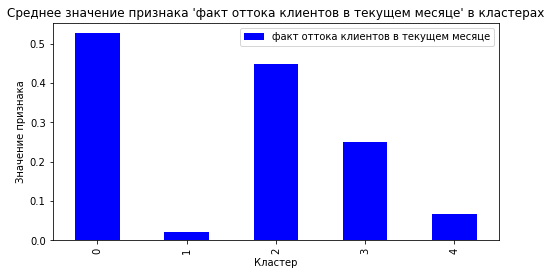

In [47]:
gym_grouped['факт оттока клиентов в текущем месяце'] = gym_grouped['churn']
cluster_barplot('факт оттока клиентов в текущем месяце')

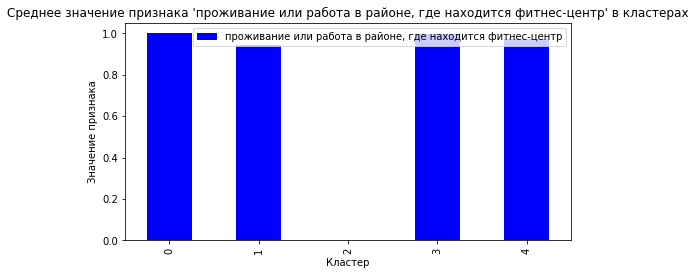

In [48]:
gym_grouped['проживание или работа в районе, где находится фитнес-центр'] = gym_grouped['near_location']
cluster_barplot('проживание или работа в районе, где находится фитнес-центр')

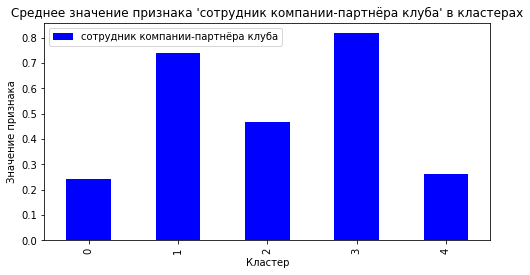

In [49]:
gym_grouped['сотрудник компании-партнёра клуба'] = gym_grouped['partner']
cluster_barplot('сотрудник компании-партнёра клуба')

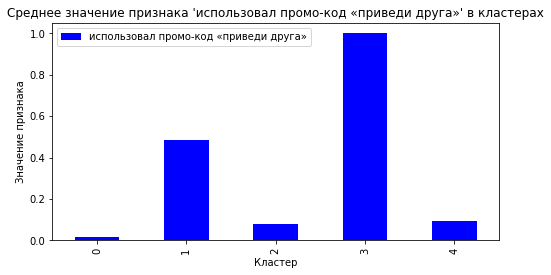

In [50]:
gym_grouped['использовал промо-код «приведи друга»'] = gym_grouped['promo_friends']
cluster_barplot('использовал промо-код «приведи друга»')

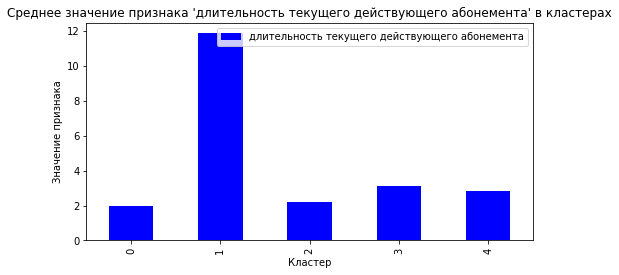

In [51]:
gym_grouped['длительность текущего действующего абонемента'] = gym_grouped['contract_period']
cluster_barplot('длительность текущего действующего абонемента')

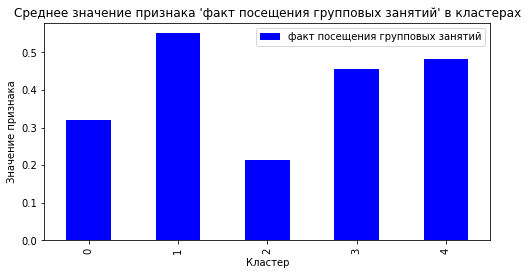

In [52]:
gym_grouped['факт посещения групповых занятий'] = gym_grouped['group_visits']
cluster_barplot('факт посещения групповых занятий')

In [53]:
# зададим функцию, позволяющую визуально оценить, как различаются значения определенного признака среди разных кластеров
def cluster_boxplot(feature):
    plt.figure(figsize=(8, 3))
    plt.boxplot([gym_filtered.query('label == 0')[feature], 
                 gym_filtered.query('label == 1')[feature], 
                 gym_filtered.query('label == 2')[feature], 
                 gym_filtered.query('label == 3')[feature], 
                 gym_filtered.query('label == 4')[feature]])
    plt.title(f"Распределение клиентов в кластерах в зависимости \n от признака '{feature}'")
    plt.xlabel('Кластер')
    plt.ylabel('Значение признака') 
    plt.xticks([1, 2, 3, 4, 5], [0, 1, 2, 3, 4])
    plt.show()

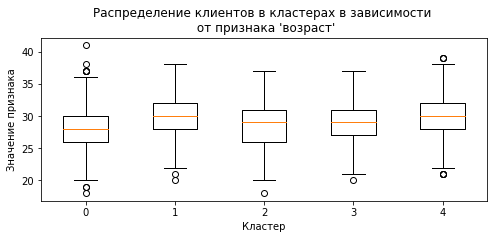

In [54]:
gym_filtered['возраст'] = gym_filtered['age']
cluster_boxplot('возраст')

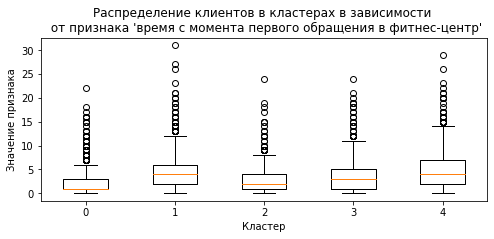

In [55]:
gym_filtered['время с момента первого обращения в фитнес-центр'] = gym_filtered['lifetime']
cluster_boxplot('время с момента первого обращения в фитнес-центр')

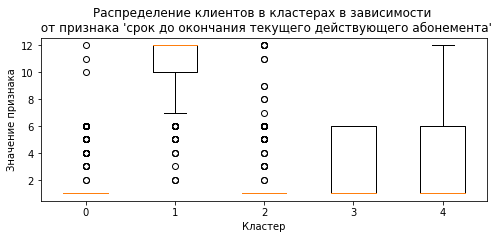

In [56]:
gym_filtered['срок до окончания текущего действующего абонемента'] = gym_filtered['month_to_end_contract']
cluster_boxplot('срок до окончания текущего действующего абонемента')

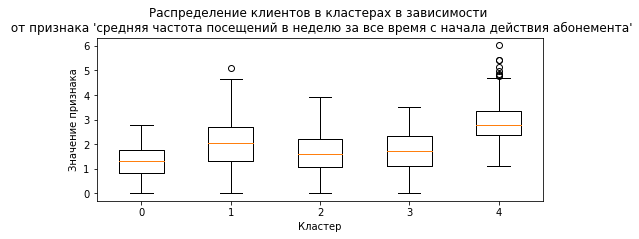

In [57]:
gym_filtered['средняя частота посещений в неделю за все время с начала действия абонемента'] = gym_filtered['avg_class_frequency_total']
cluster_boxplot('средняя частота посещений в неделю за все время с начала действия абонемента')

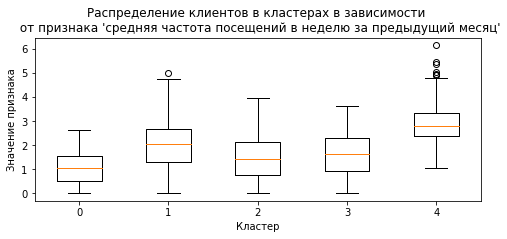

In [58]:
gym_filtered['средняя частота посещений в неделю за предыдущий месяц'] = gym_filtered['avg_class_frequency_current_month']
cluster_boxplot('средняя частота посещений в неделю за предыдущий месяц')

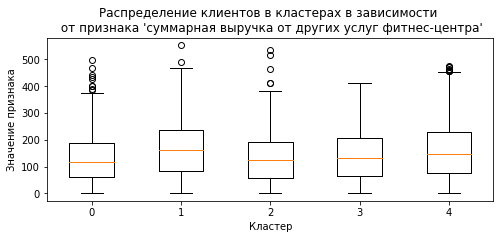

In [59]:
gym_filtered['суммарная выручка от других услуг фитнес-центра'] = gym_filtered['avg_additional_charges_total']
cluster_boxplot('суммарная выручка от других услуг фитнес-центра')

<b> Характеристики клиентов по кластерам: </b>  

<u> Кластер 0: </u>  
+ почти никто из клиентов не уйдёт через месяц;  
+ клиенты живут или работают вблизи фитнес-центра;  
+ в среднем абонементы клиентов на 3 месяца;  
+ почти половина клиентов посещает групповые занятия;  
+ посещают зал 2-3 раза в неделю.  

<u> Кластер 1: </u>  
+ около 50% клиентов уйдут через месяц;  
+ клиенты живут или работают вблизи фитнес-центра;  
+ мало клиентов от компании-партнера;  
+ малый процент пришедших клиентов по промокоду;  
+ абонементы клиентов заканчиваются через месяц;  
+ посещают зал редко, 1 раз в неделю.  

<u> Кластер 2: </u>  
+ почти половина клиентов уйдут через месяц;  
+ все клиенты живут и работают далеко от фитнес-центра;  
+ малый процент пришедших клиентов по промокоду;  
+ мало посещают групповые занятия;  
+ абонементы клиентов заканчиваются через месяц;  

<u> Кластер 3: </u>  
+ примерно четверть клиентов уйдут через месяц;  
+ клиенты живут или работают вблизи фитнес-центра;  
+ много клиентов от компании-партнера;   
+ все клиенты пришли по промокоду;   
+ в среднем абонементы клиентов на 3 месяца;   
+ абонемент у половины клиентов заканчивается через 1 месяц.  

<u> Кластер 4: </u>  
+ через месяц уйдёт небольшой процент клиентов;  
+ клиенты живут или работают вблизи фитнес-центра;  
+ много клиентов от компании-партнера;  
+ абонементы клиентов в срднем на 12 месяцев;  
+ больше половины ходят на групповые занятия;  
+ можно сказать возрастной кластер.

<b>5.6. Подсчет доли оттока для каждого полученного кластера.</b>
<a id='5.6'></a>

In [60]:
# посчитаем средний процент оттока пользователей для каждого кластера
(gym_grouped
     .groupby('label')['churn']
     .mean()
     .reset_index()
     .sort_values(by='churn', ascending=False)
     .reset_index(drop=True))

,label,churn
0,0,0.53
1,2,0.45
2,3,0.25
3,4,0.07
4,1,0.02


Большая доля оттока в 1 и 2 кластерах, 53% и 45% соответственно.  
В класетере 3 отток клиентов умеренный - 25%.  
Самые надежные кластеры это 0 и 4, там отток составляет 7% и 2% соответственно.

<h1>6. Выводы и рекомендации.</h1>
<a id='6'></a>

В результате проведенного исследования данных о клиентах фитнес-центра «Культурист-датасаентист» были выявлены ключевые характеристики, влияющие на уровень лояльности и оттока клиентов. Анализ показал, что 27% клиентов находятся в состоянии оттока, и на основе полученных данных были сформированы два четких портрета: "лояльные клиенты" и "ушедшие клиенты".

Лояльные клиенты — это мужчины и женщины в возрасте 28-32 лет, проживающие или работающие рядом с фитнес-центром, часто являющиеся сотрудниками компаний-партнеров. Они активно участвуют в акциях, охотно оставляют контактные данные и предпочитают долгосрочные абонементы. Эти клиенты посещают групповые занятия, имеют высокую частоту посещений и приносят значительную выручку от дополнительных услуг.

Ушедшие клиенты, напротив, это мужчины и женщины в возрасте 25-29 лет, которые не живут или не работают поблизости от центра. Они реже участвуют в акциях, менее охотно оставляют контактные данные и предпочитают краткосрочные абонементы. Эти клиенты имеют низкую частоту посещений и приносят меньшую выручку.

Анализ показал наличие двух кластеров с полярными характеристиками: "лояльные клиенты" с низким уровнем оттока (12%) и "нелояльные клиенты" с высоким уровнем оттока (40%). Общими для всех кластеров являются пол клиента и наличие контактного телефона, что не влияет на уровень лояльности.

На основе полученных результатов рекомендуется:

+ Разрабатывать стратегии привлечения и удержания клиентов с акцентом на возрастную группу 27-33 года, особенно на клиентов старше 30 лет.  
+ Уделять равное внимание как мужчинам, так и женщинам.  
+ Сосредоточить усилия на привлечении жителей района и сотрудников компаний-партнеров.  
+ Сделать долгосрочные абонементы более привлекательными, а краткосрочные — менее.  
+ Повышать интерес к групповым занятиям через акции (например, бесплатное первое занятие).  
+ Регулярно проводить акции типа "Приведи друга", которые способствуют привлечению лояльных клиентов.  
+ Мониторить частоту посещений клиентов и предлагать специальные условия при снижении этого показателя.  

Эти рекомендации помогут повысить уровень удержания клиентов и снизить отток из фитнес-центра.